# Correlators, structure factors and thermodynamics from sampling
Once a classical model is being sampled by Monte Carlo, the configurations it visits carry
the thermodynamics and the correlations of the model. `get_correlator()` gives the connected
correlator $G(r)=\langle\delta n_i\,\delta n_j\rangle$ between sites at distance $r$, averaged
over all such pairs, the density-density correlator of a `LatticeGas` and the spin-spin
correlator of a `LatticeIsing`, and `get_structure_factor()` gives its reciprocal-space
counterpart

$$
S(\mathbf q)=\frac{1}{N}\Big|\sum_i \delta n_i\,e^{-i\mathbf q\cdot\mathbf r_i}\Big|^2
$$

with $\delta n_i$ the deviation from the mean, whose peaks locate the ordering wavevector. The
fluctuations of an equilibrium trajectory at fixed temperature give the response functions:
`latticegas.get_specific_heat()` computes $C=\mathrm{Var}(E)/T^2$ from the energy along the run,
and `latticegas.get_susceptibility()` computes $\chi=\mathrm{Var}(N)/T$ from the filling of a
lattice gas, or the magnetization of an Ising model, along it.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import supercell
from pyqula import latticegas
from pyqula import latticeising
np.random.seed(3) # reproducible Monte Carlo runs

### Specific heat and susceptibility across the Ising transition
We cool the square-lattice Ising ferromagnet step by step, reusing the configuration of the
previous temperature, and at each temperature discard the first half of the run as
equilibration. The magnetization rises below the transition, at $T_c\approx2\times2.269$ in
these units since each bond is counted twice, and both the specific heat and the
susceptibility peak there; on a finite lattice the peaks are rounded and slightly shifted,
and they sharpen as the lattice grows.

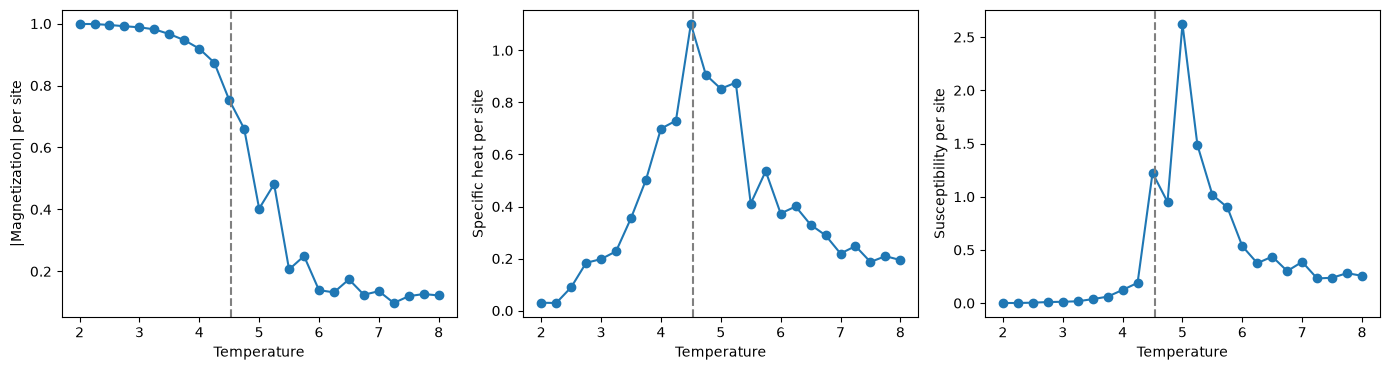

In [2]:
L = 16
g = geometry.square_lattice().get_supercell(L) # periodic supercell
li = latticeising.LatticeIsing(g,m=0.0)
li.add_interaction(Jij=[1.]) # first-neighbor ferromagnetic coupling
n = li.nsites

temps = np.linspace(8.,2.,25) # from high to low temperature
mags,cs,chis = [],[],[]
for T in temps:
    es,ms = li.optimize_energy(temp=T,ntries=400*n) # Metropolis, 400 sweeps
    es,ms = es[len(es)//2:],ms[len(ms)//2:] # discard the equilibration
    mags.append(np.mean(np.abs(ms))/n)
    cs.append(latticegas.get_specific_heat(es,T,burn=0.)/n)
    chis.append(latticegas.get_susceptibility(np.abs(ms),T,burn=0.)/n)

fig,axs = plt.subplots(1,3,figsize=(14,3.8))
for ax,y,lab in zip(axs,[mags,cs,chis],["|Magnetization| per site",
                                        "Specific heat per site","Susceptibility per site"]):
    ax.plot(temps,y,marker="o")
    ax.axvline(2*2.269,c="gray",ls="--")
    ax.set_xlabel("Temperature") ; ax.set_ylabel(lab)
plt.tight_layout()
plt.show()

### The ordering wavevector in the structure factor
The structure factor of an ordered snapshot peaks at the ordering wavevector, and it is the
quantity a scattering experiment measures. The Ising antiferromagnet on the square lattice
orders in a checkerboard, with peaks at $(\pm\pi,\pm\pi)$, the corners of the Brillouin zone;
a lattice gas at a third filling on the triangular lattice with a first-neighbor repulsion
orders in the $\sqrt3\times\sqrt3$ structure, with peaks at the K points of its Brillouin zone,
the corners of a hexagon. Both maps are taken on low-temperature snapshots; the peaks of the
lattice gas are split, a trace of the domain walls between differently ordered regions that the
anneal leaves in the snapshot, which is also why its energy is not exactly zero.

Energy per site of the lattice gas: 0.05555555555555555


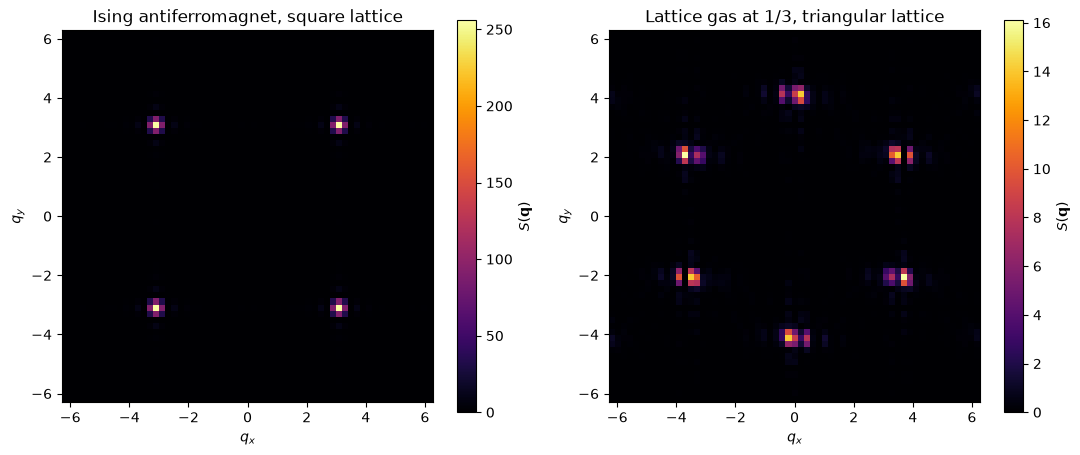

In [3]:
li = latticeising.LatticeIsing(g,m=0.0)
li.add_interaction(Jij=[-1.]) # first-neighbor antiferromagnetic coupling
li.anneal(temps=np.geomspace(8.,0.5,10),ntries=40*n) # cool it down
nq = 61
qa,sa = li.get_structure_factor(nq=nq,qmax=2*np.pi) # checkerboard order

gt = geometry.triangular_lattice()
gt = supercell.turn_orthorhombic(gt) # rectangular cell
gt = gt.get_supercell(12) # periodic, compatible with the three-sublattice order
lg = latticegas.LatticeGas(gt,filling=1./3.)
lg.add_interaction(Jij=[1.]) # first-neighbor repulsion
lg.anneal(temps=np.geomspace(2.,0.05,10),ntries=100*lg.nsites)
print("Energy per site of the lattice gas:",lg.get_energy()/lg.nsites) # zero if perfectly ordered
qg,sg = lg.get_structure_factor(nq=nq,qmax=2*np.pi) # sqrt(3) x sqrt(3) order

fig,axs = plt.subplots(1,2,figsize=(11,4.5))
for ax,sq,t in zip(axs,[sa,sg],["Ising antiferromagnet, square lattice",
                                "Lattice gas at 1/3, triangular lattice"]):
    im = ax.imshow(sq.reshape(nq,nq).T,origin="lower",cmap="inferno",
                   extent=[-2*np.pi,2*np.pi,-2*np.pi,2*np.pi])
    plt.colorbar(im,ax=ax,label="$S(\\mathbf{q})$")
    ax.set_xlabel("$q_x$") ; ax.set_ylabel("$q_y$") ; ax.set_title(t)
plt.tight_layout()
plt.show()

### Correlations growing as the temperature goes down
Let us now follow the Ising antiferromagnet through its transition. The map is the structure
factor along the diagonal of the Brillouin zone, $\mathbf q=(q,q)$, as a function of
temperature, averaged over a few snapshots at each temperature and drawn on a logarithmic
color scale: above the transition it is a broad bump, and below it a sharp Bragg peak at
$q=\pi$. The right panel is the spin-spin
correlator $G(r)$ at the first few distances, whose sign follows the checkerboard, negative
between sites of different sublattices and positive within one; above the transition it
decays with distance, while below it it stays finite at every distance, the long-range order.

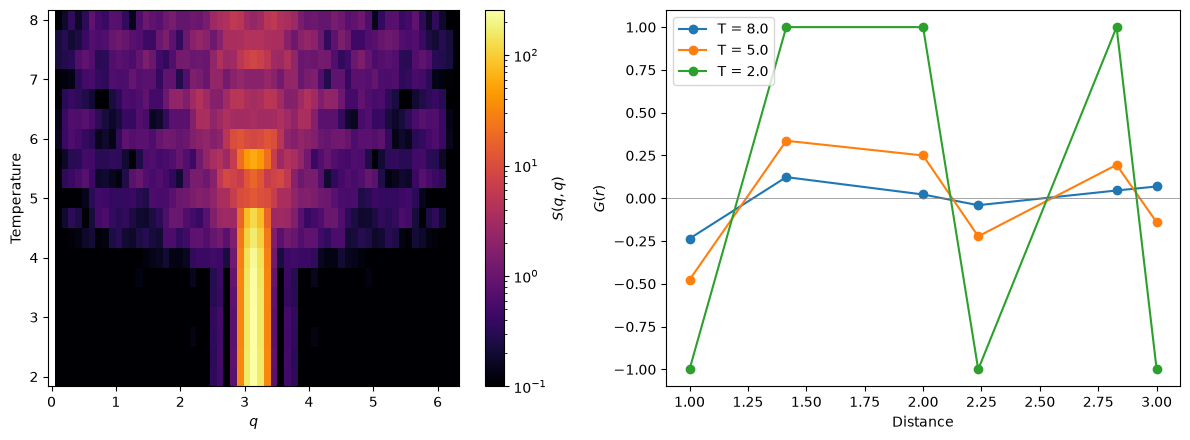

In [4]:
li = latticeising.LatticeIsing(g,m=0.0)
li.add_interaction(Jij=[-1.])
qs = np.linspace(0.,2*np.pi,61)
qpath = [[q,q,0.] for q in qs] # diagonal of the Brillouin zone
temps = np.linspace(8.,2.,19) # from high to low temperature
smap = np.zeros((len(temps),len(qs)))
gr = {}
for i,T in enumerate(temps):
    li.optimize_energy(temp=T,ntries=100*n) # equilibrate
    for j in range(5): # average over snapshots
        li.optimize_energy(temp=T,ntries=10*n)
        smap[i] += li.get_structure_factor(qpath=qpath)[1]/5
    if i in [0,9,18]: gr[T] = li.get_correlator(n=6) # distance, correlator

fig,axs = plt.subplots(1,2,figsize=(12,4.5))
from matplotlib.colors import LogNorm
im = axs[0].pcolormesh(qs,temps,smap,shading="nearest",cmap="inferno",
                       norm=LogNorm(vmin=0.1,vmax=smap.max())) # logarithmic color scale
plt.colorbar(im,ax=axs[0],label="$S(q,q)$")
axs[0].set_xlabel("$q$") ; axs[0].set_ylabel("Temperature")
for T,(r,c) in gr.items():
    axs[1].plot(r,c,marker="o",label=f"T = {T:.1f}")
axs[1].axhline(0.,c="gray",lw=0.5)
axs[1].set_xlabel("Distance") ; axs[1].set_ylabel("$G(r)$") ; axs[1].legend()
plt.tight_layout()
plt.show()